# Label zones

Assign each cell to a spatial zone by interpreting the CellCharter spatial clusters from [04_cellcharter.ipynb](04_cellcharter.ipynb). Each CellCharter cluster is mapped to an interpretable zone (TLS, bronchi, vessels, adventitia, parenchyma, capsule)

**Pinned Environment:** [`conda_envs/space2_20250604.yml`](../conda_envs/space2_20250604.yml)  

In [25]:
from pathlib import Path
import sys
import os
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata
import scanpy as sc
import squidpy as sq

import pickle

from scipy.spatial.distance import cdist

import random
import colorcet

In [26]:
warnings.simplefilter(action='ignore', category=Warning)

## Local file info

In [27]:
sys.path.append(str(Path.cwd().resolve().parents[0]))

from config.paths import BASE_OUTDIR, INPUTS_DIR, FUNCTIONS_DIR

inputs_dir = INPUTS_DIR
out_dir = os.path.join(BASE_OUTDIR, "merge_labels")
labels_dir = os.path.join(BASE_OUTDIR, "cell_labeling/ouputs_mouselung_hurskainen_ref_consolidate_labels_xenseg_HDM")
cellcharter_dir = os.path.join(BASE_OUTDIR, "cellcharter_analysis/outputs_mouselung_batchcorrect_xenseg_nb") 
seurat_outs_dir = os.path.join(labels_dir, "cite_integration/seurat_obj_outs/cite_xen_integrated")

print(inputs_dir)
print(out_dir)

/home/workspace/spatial_tls_manuscript/inputs
/home/workspace/spatial_mouse_lung_outputs/merge_labels


In [28]:
import importlib
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

# import plotting functions as pu
import plotting_utils as pu

## Load adata

In [50]:
# adata saved in 05_merge_cell_labels.ipynb
adata = sc.read_h5ad(os.path.join(out_dir,'adata_labeled.h5ad'))

In [51]:
# add cellcharter zones
cellcharter_zones_filepath = os.path.join(cellcharter_dir,'adata_scvi_cellcharter_zone_cols.csv')
cellcharter_df = pd.read_csv(cellcharter_zones_filepath, index_col=0)

matching_cells = adata.obs_names.intersection(cellcharter_df.index)
for col in cellcharter_df.columns:
    adata.obs.loc[matching_cells, col] = cellcharter_df.loc[matching_cells, col]
    adata.obs[col] = adata.obs[col].astype('category')


## Load celltype palettes

In [52]:
with open(os.path.join(inputs_dir, 'palettes/20250519_celltype_palette_mapped.pkl'), 'rb') as f:
    celltype_palette_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarse_mapped.pkl'), 'rb') as f:
    celltype_palette_coarse_mapped = pickle.load(f)

with open(os.path.join(inputs_dir, 'palettes/20250520_celltype_palette_coarser_mapped.pkl'), 'rb') as f:
    celltype_palette_coarser_mapped = pickle.load(f)


## Evaluate and label zones

Inspect the CellCharter clusters (`cluster_cellcharter_12`) against marker expression and spatial position to decide which cluster number maps to each zone. In the plots below:
- **TLS** — the cluster overlapping the `Cd79a`-high (B cell) spatial regions
- **bronchi** / **vessels** / **adventitia** / **parenchyma** — identified by their spatial structure and cell type composition

In [53]:
unique_values = list(range(13))
palette = sns.color_palette(colorcet.glasbey, n_colors=len(unique_values)) 
random.shuffle(palette)

zone_palette_mapped = {val: color for val, color in zip(unique_values, palette)}

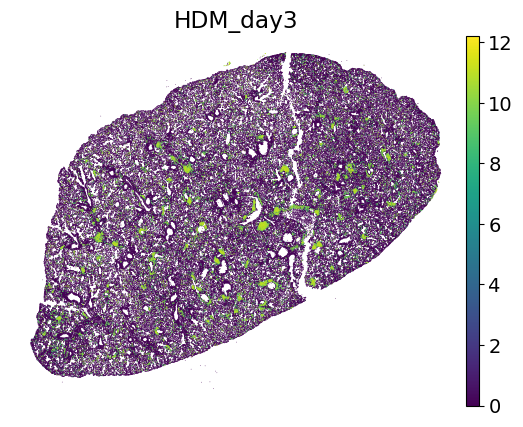

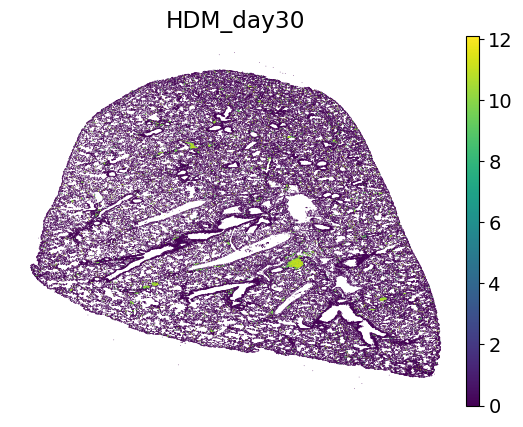

In [54]:
# Cd79 expression
for sample_label in adata.obs['sample_label'].cat.categories:
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    sc.pl.embedding(adata_plot, basis='spatial', color='Cd79a', title=sample_label, frameon=False, size=1)

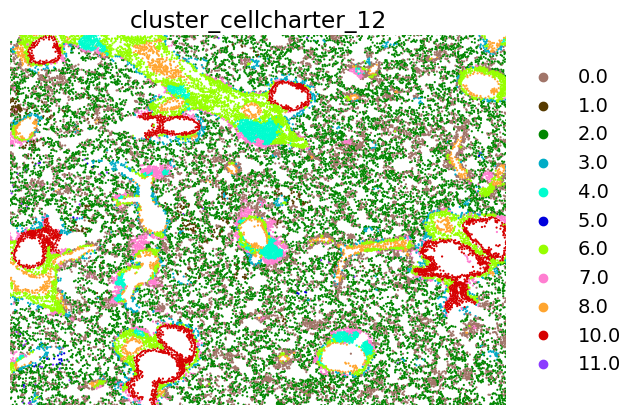

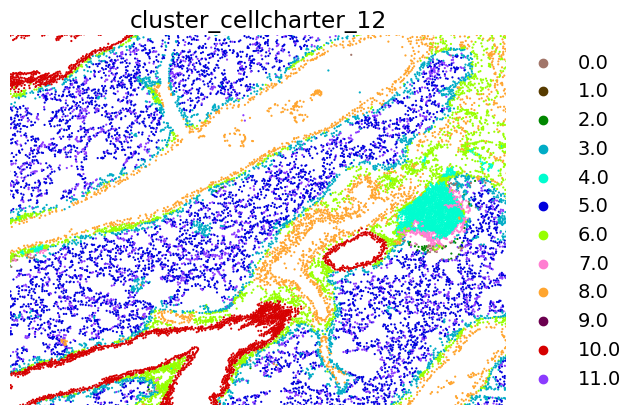

In [55]:
for sample_label in adata.obs['sample_label'].cat.categories:
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    sc.pl.embedding(adata_plot, basis='spatial', color='cluster_cellcharter_12', palette=zone_palette_mapped, frameon=False, 
                    size=10, 
                    show=False)
    plt.xlim([3000, 5000])
    plt.ylim([3000, 5000])
    plt.show()

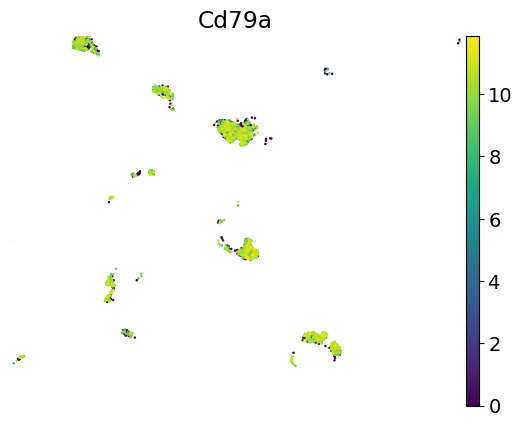

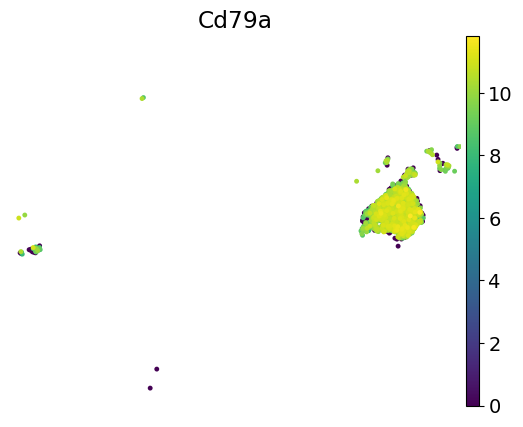

In [56]:
for sample_label in adata.obs['sample_label'].cat.categories:
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    adata_plot = adata_plot[adata_plot.obs['cluster_cellcharter_12']==4, :]
    sc.pl.embedding(adata_plot, basis='spatial', color='Cd79a', palette=zone_palette_mapped, frameon=False, 
                    # size=10, 
                    show=False)
    plt.xlim([3000, 5000])
    plt.ylim([3000, 5000])
    plt.show()

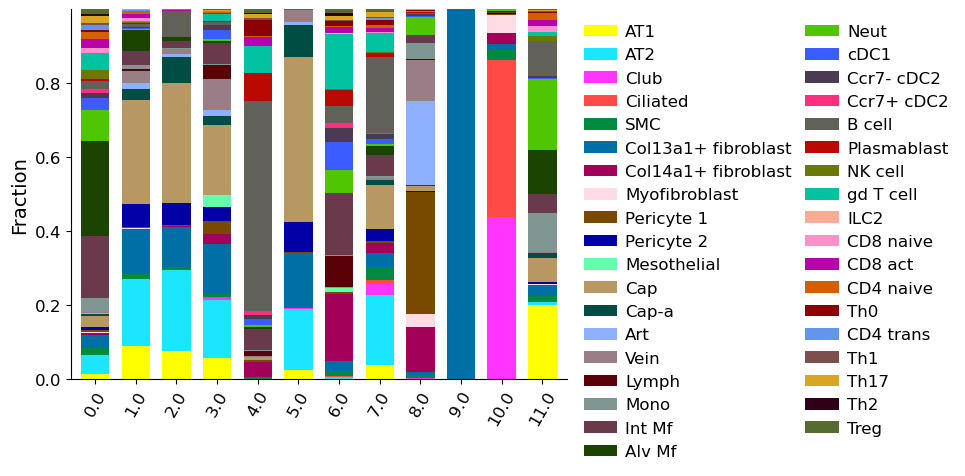

In [57]:
# zone composition by celltype
zone_col = 'cluster_cellcharter_12'
label_col = 'label_fine'


ax1 = pu.zone_composition(adata, label_col, zone_col,
                            remove_unlabeled = True, 
                       palette_map = celltype_palette_mapped,
                       plot_counts=False
                      )
ax1.tick_params(axis='x', labelsize=12, rotation=60)
ax1.tick_params(axis='y', labelsize=12)

## Zone consolidation

Based on the visual inspection above, each CellCharter cluster (`cluster_cellcharter_12`) is manually mapped to a zone label via the `zone_map` dictionary, then the categories are ordered.

In [58]:
# make zone categories
zone_map = {
    0: 'parenchyma', 
    1: 'parenchyma',
    2: 'parenchyma',
    3: 'adventitia', 
    4: 'TLS',
    5: 'parenchyma',
    6: 'adventitia',
    7: 'TLS',
    8: 'vessels',
    9: 'parenchyma',
    10: 'bronchi',
    11: 'parenchyma'
    }

# map to adata
adata.obs['zone_consol'] = (
    adata.obs['cluster_cellcharter_12'].map(zone_map))
# order zone categories
zone_order = ["TLS", "bronchi","vessels", "adventitia", "parenchyma"] 
adata.obs["zone_consol"] = pd.Categorical(
    adata.obs["zone_consol"], categories=zone_order, ordered=True
)

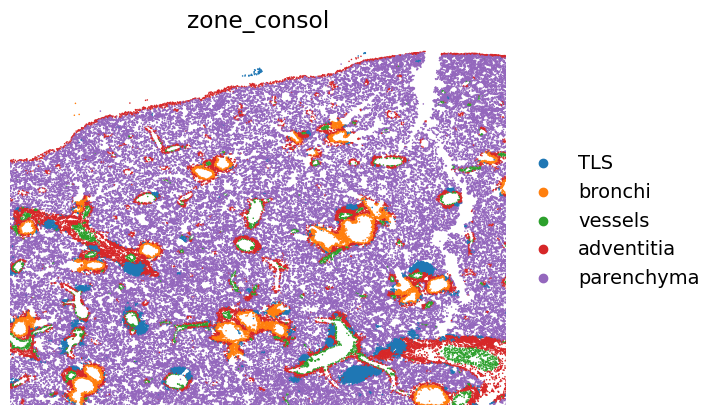

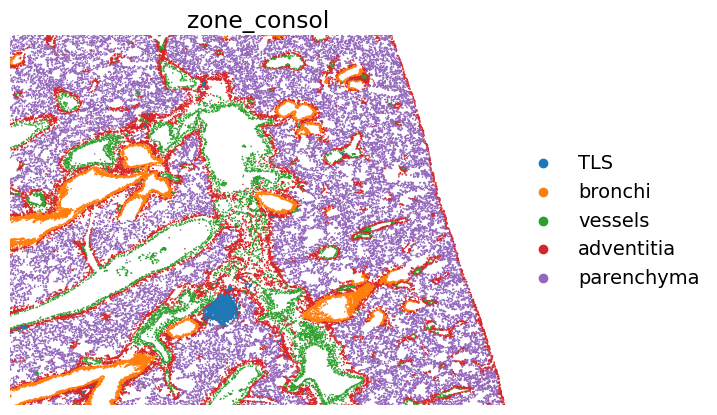

In [49]:
for sample_label in adata.obs['sample_label'].cat.categories:
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    sc.pl.embedding(adata_plot, basis='spatial', color='zone_consol', frameon=False, 
                    size=5, 
                    show=False)
    plt.xlim([3000, 7000])
    plt.ylim([3000, 7000])
    plt.show()

### Separate capsule from adventia zone
- Capsule are cells that localize with mesothelial cells, which are specifically located in the capsule
- For all cells in adventitia zone, calculate distance to closest n mesothelial cells
- Use this distance to make a binary classification between adventitia and capsule

In [15]:
def cell_dist_to_other_celltype(adata, cell_type_col, other_cell_type_col, other_cell_type, nearest_n):
    """
    For each unique cell type in `cell_type_col`, compute the average distance to its `nearest_n` 
    closest cells of a specified other cell type (e.g., a landmark or reference type).

    The function stores the resulting distances in a new column of `adata.obs`, named 
    `avg_distance_to_<other_cell_type>`.

    Parameters
    ----------
    adata : AnnData
        Annotated data matrix with `.obs` columns for cell types and centroid coordinates.

    cell_type_col : str
        Column in `adata.obs` containing cell type identities to compute distances from.

    other_cell_type_col : str
        Column in `adata.obs` specifying the identity of the comparison group (e.g., cell type, state, region).

    other_cell_type : str
        Value in `other_cell_type_col` to which distances will be computed.

    nearest_n : int
        Number of nearest neighboring cells to include in the average distance calculation.

    Returns
    -------
    AnnData
        Updated `adata` object with a new column in `.obs` containing average distances 
        to the `other_cell_type`.
    """
    
    # get coordinates of other cell type (the one we want to calculate the distance to)
    adata_other_type = adata[adata.obs[other_cell_type_col] == other_cell_type, :]
    other_cell_type_coords = adata_other_type.obs[['x_centroid', 'y_centroid']].values
    
    # Iterate over each unique cell type
    for cell_type in adata.obs[cell_type_col].unique():
        
        # Filter AnnData object for the current cell type
        adata_filtered = adata[adata.obs[cell_type_col] == cell_type, :]
        adata_filtered_cell_type_indices = adata_filtered.obs.index
    
        # Get the coordinates of the cells of the current type
        cell_type_coords = adata_filtered.obs[['x_centroid', 'y_centroid']].values
        
        # Calculate the pairwise distances between the current cell type and other cell type
        pairwise_distances = cdist(cell_type_coords, other_cell_type_coords, metric='euclidean')
    
        # Sort distances and select nearest n
        nearest_distances = np.sort(pairwise_distances, axis=1)[:, :nearest_n]
        
        # Calculate the average distance to the nearest n cells
        avg_distance = np.mean(nearest_distances, axis=1)

        # Store distances in adata.obs 

        # column name to store distance to other type
        dist_col = 'avg_distance_to_' + other_cell_type
        
        # Assigning values to the new column in the original DataFrame, using cell type filtered adata indices
        adata.obs.loc[adata_filtered_cell_type_indices, dist_col] = avg_distance

    return adata

In [16]:
adata_advent = adata[adata.obs['zone_consol']=='adventitia', :].copy()

cell_type_col = 'label_fine'
other_cell_type_col = 'label_fine'
other_cell_type = 'Mesothelial' 
dist_col = f'avg_distance_to_{other_cell_type}'
nearest_n = 5 

start_time = time.time()

adata_advent.obs[dist_col] = np.nan

for sample_label in adata_advent.obs['sample_label'].cat.categories:
    
    print(sample_label)

    adata_sample = adata_advent[adata_advent.obs['sample_label']==sample_label, :]
    
    # run distance calculation for each sample 
    adata_sample = cell_dist_to_other_celltype(adata_sample, cell_type_col, other_cell_type_col, other_cell_type, nearest_n)
    
    # get distance df for each structure and add it back to the main adata object
    dist_df = adata_sample.obs[[dist_col]] 
    adata_advent.obs.loc[dist_df.index, dist_col] = dist_df[dist_col]

adata_advent.obs[dist_col] = pd.to_numeric(adata_advent.obs[dist_col])
end_time = time.time()
elapsed_time = (end_time - start_time) / 60
print(elapsed_time, ' min')


HDM_day3
HDM_day30
0.10269963343938192  min


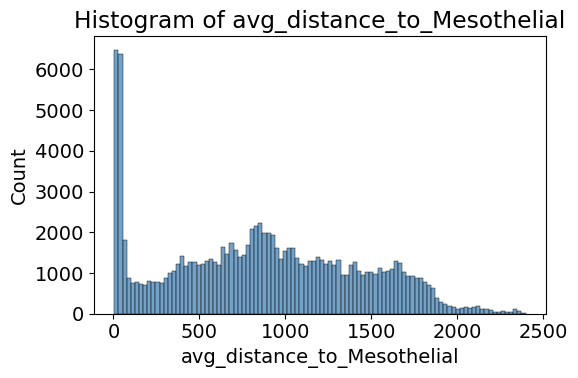

In [17]:
plt.figure(figsize=(6, 4))
sns.histplot(adata_advent.obs[dist_col], bins=100, kde=False, color='steelblue')
plt.xlabel(dist_col)
plt.ylabel('Count')
plt.title(f'Histogram of {dist_col}')
plt.tight_layout()
plt.show()

In [18]:
capsule_cells = adata_advent.obs_names[adata_advent.obs[dist_col] < 100]
adata.obs['zone_consol'] = adata.obs['zone_consol'].astype(str)
adata.obs.loc[capsule_cells, 'zone_consol'] = 'capsule'

In [19]:
# Reset zone category order after adding capsule
zone_order = ["TLS", "bronchi","vessels", "adventitia", "parenchyma", "capsule"] 
adata.obs["zone_consol"] = pd.Categorical(
    adata.obs["zone_consol"], categories=zone_order, ordered=True
)

### Zone palette

In [20]:
zone_consol_palette_mapped = {
    'TLS': 'darkgreen',
 'bronchi': 'midnightblue',
    'vessels': 'maroon',
 'adventitia': 'darkorange',
 'parenchyma': 'lightsteelblue',
    'capsule': 'slategrey',
}

In [21]:
with open(os.path.join(inputs_dir, 'palettes/20250521_zone_consol_palette_mapped.pkl'), 'wb') as f:
    pickle.dump(zone_consol_palette_mapped, f)

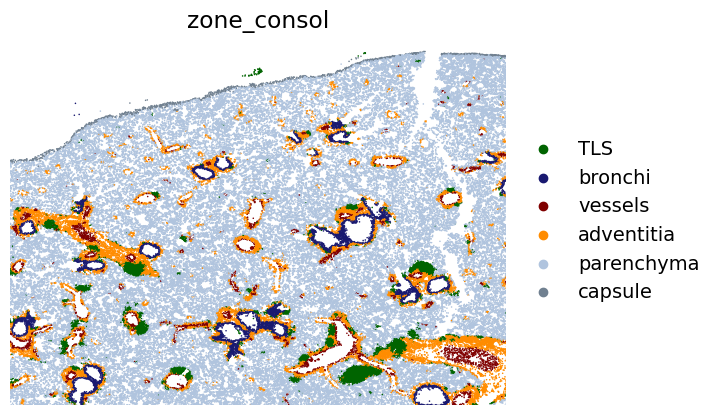

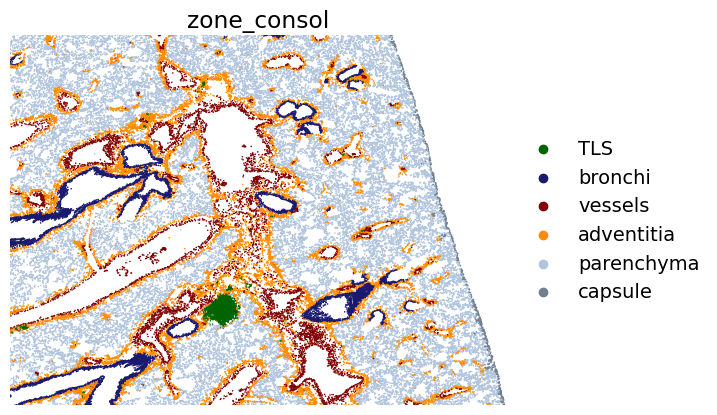

In [22]:
for sample_label in adata.obs['sample_label'].cat.categories:
    adata_plot = adata[adata.obs['sample_label']==sample_label, :]
    sc.pl.embedding(adata_plot, basis='spatial', color='zone_consol', palette=zone_consol_palette_mapped, frameon=False, 
                    size=5, 
                    show=False)
    plt.xlim([3000, 7000])
    plt.ylim([3000, 7000])
    plt.show()

# Save adata 

In [23]:
adata.write_h5ad(os.path.join(out_dir,'adata_labeled_zones.h5ad'), compression='gzip')


In [24]:
import session_info
print('active conda environment: ', os.path.basename(sys.prefix))
session_info.show(excludes=['google3'])

active conda environment:  space2
